<a href="https://colab.research.google.com/github/sjlee53/ESAA-submission/blob/main/%EC%8B%9C%EA%B0%81%ED%99%94_%ED%9B%84%EB%B3%B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/sjlee53/ESAA-submission/main/project/data/movies_train.csv'
df = pd.read_csv(url)

print(df.shape)
df.head()

(600, 12)


,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


In [8]:
!apt-get -qq install fonts-nanum

import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')                      # 먼저
plt.rcParams['font.family'] = 'NanumGothic'     # 나중
plt.rcParams['axes.unicode_minus'] = False

Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


In [3]:
#전처리
df['dir_prev_bfnum'] = df['dir_prev_bfnum'].fillna(0)
df['release_time'] = pd.to_datetime(df['release_time'])
df['연도'] = df['release_time'].dt.year
df['월'] = df['release_time'].dt.month

df['규모'] = pd.cut(df['num_staff'], [-1, 80, 250, 900],
                  labels=['소(~80명)', '중(81~250명)', '대(251명~)'])
df['감독'] = np.where(df['dir_prev_num'] == 0, '신인', '경력')
df['log관객수'] = np.log10(df['box_off_num'])

df[['title', 'genre', 'time', 'num_staff', '규모', 'box_off_num']].head()

,title,genre,time,num_staff,규모,box_off_num
0,개들의 전쟁,액션,96,91,중(81~250명),23398
1,내부자들,느와르,130,387,대(251명~),7072501
2,은밀하게 위대하게,액션,123,343,대(251명~),6959083
3,나는 공무원이다,코미디,101,20,소(~80명),217866
4,불량남녀,코미디,108,251,대(251명~),483387


3번

In [5]:
from scipy import stats

# ══════════════════════════════════════════════════════
# 1) 전체에 쏠림이 있는가 — 기준선과 비교
#    상영시간이 무작위라면 5의 배수는 20%, 10의 배수는 10%여야 한다
# ══════════════════════════════════════════════════════
print('=' * 55)
print('1) 전체 쏠림')
print('=' * 55)
print('5의 배수 : %.1f%%  (무작위면 20%%)' % ((df['time'] % 5 == 0).mean() * 100))
print('10의 배수: %.1f%%  (무작위면 10%%)' % ((df['time'] % 10 == 0).mean() * 100))
print()
print('가장 흔한 상영시간 10개')   # 90분·100분이 위에 오면 쏠림의 직접 증거
print(df['time'].value_counts().head(10).to_string())

# ══════════════════════════════════════════════════════
# 2) 제작 규모에 따라 갈리는가
#    소→대로 갈수록 비율이 줄면 '작을수록 딱 떨어진다'는 가설과 맞는다
# ══════════════════════════════════════════════════════
print()
print('=' * 55)
print('2) 규모별')
print('=' * 55)
g = df.groupby('규모', observed=True).agg(
    편수=('time', 'size'),
    배수5=('time', lambda s: round((s % 5 == 0).mean() * 100, 1)),
    배수10=('time', lambda s: round((s % 10 == 0).mean() * 100, 1)),
    상영시간중앙=('time', 'median'))
print(g.to_string())

# ══════════════════════════════════════════════════════
# 3) 0 때문인가 5 때문인가 — 끝자리를 0~9로 펼쳐서 확인
#    "5의 배수가 많다"만으로는 어느 쪽이 솟았는지 알 수 없다
#    ★ 이 표가 그래프 종류를 결정한다
# ══════════════════════════════════════════════════════
print()
print('=' * 55)
print('3) 끝자리 0~9 분포 (%)')
print('=' * 55)
df['끝자리'] = df['time'] % 10
끝자리표 = (pd.crosstab(df['규모'], df['끝자리'], normalize='index') * 100).round(1)
print(끝자리표.to_string())

# ══════════════════════════════════════════════════════
# 4) 우연인가 — 카이제곱 검정
#    p < 0.05면 "우연으로 보기 어렵다"
# ══════════════════════════════════════════════════════
print()
print('=' * 55)
print('4) 카이제곱 검정')
print('=' * 55)
tab = pd.crosstab(df['규모'], df['time'] % 5 == 0)
print(tab.to_string())
print()
print('소·중·대 전체 p = %.4f' % stats.chi2_contingency(tab)[1])
print('소 vs 대    p = %.4f' % stats.chi2_contingency(tab.iloc[[0, 2]])[1])

# ══════════════════════════════════════════════════════
# 5) 차이의 크기 — 몇 편이나 더 많은가
#    비율(%)만으로는 체감이 안 되니 실제 편수로 환산
# ══════════════════════════════════════════════════════
print()
print('=' * 55)
print('5) 관측 vs 기대 편수')
print('=' * 55)
for 규모 in df['규모'].cat.categories:
    d = df[df['규모'] == 규모]
    관측 = (d['time'] % 5 == 0).sum()
    기대 = len(d) * 0.2
    print('%-12s %3d편 중 5의 배수 %2d편  (기대 %4.1f편, 차이 %+.1f)'
          % (규모, len(d), 관측, 기대, 관측 - 기대))

1) 전체 쏠림
5의 배수 : 24.7%  (무작위면 20%)
10의 배수: 12.2%  (무작위면 10%)

가장 흔한 상영시간 10개
time
90     17
100    17
98     16
89     15
91     15
114    15
95     15
97     15
104    14
99     14

2) 규모별
             편수   배수5  배수10  상영시간중앙
규모                                 
소(~80명)     297  28.3  14.1    91.0
중(81~250명)  138  23.9  11.6   102.0
대(251명~)    165  18.8   9.1   115.0

3) 끝자리 0~9 분포 (%)
끝자리            0     1     2    3     4     5    6     7     8     9
규모                                                                  
소(~80명)     14.1   7.4   8.4  9.1   9.8  14.1  6.7  11.1  10.1   9.1
중(81~250명)  11.6   8.7  10.1  8.7  11.6  12.3  9.4   9.4   8.0  10.1
대(251명~)     9.1  12.7  12.1  6.1  15.2   9.7  5.5  11.5   6.7  11.5

4) 카이제곱 검정
time        False  True 
규모                      
소(~80명)       213     84
중(81~250명)    105     33
대(251명~)      134     31

소·중·대 전체 p = 0.0742
소 vs 대    p = 0.0316

5) 관측 vs 기대 편수
소(~80명)      297편 중 5의 배수 84편  (기대 59.4편, 차이 +24.6)
중(81~250명)   138편 중

결과:

① 전체 쏠림 확인 — 5의 배수 24.7%, 10의 배수 12.2%. 최빈값이 90분·100분 공동 1위(17편씩).

② 규모별 단조 감소 — 28.3 → 23.9 → 18.8%. 10의 배수도 14.1 → 11.6 → 9.1로 똑같이 줄음. 두 지표가 같은 방향인 게 중요.

③ 0과 5가 함께 솟음 — 소규모는 0(14.1)과 5(14.1)가 나란히 1위, 나머지 8개는 6.7~11.1. 대규모는 0이 9.1, 5가 9.7로 평범하고 오히려 4가 15.2(노이즈).

④ 소 vs 대만 유의 — p=0.032. 전체는 p=0.074로 못 넘김.

⑤ 편수로 보면 — 소 +24.6편, 중 +5.4편, 대 −2.0편. 대규모는 오히려 기준치보다 적음.

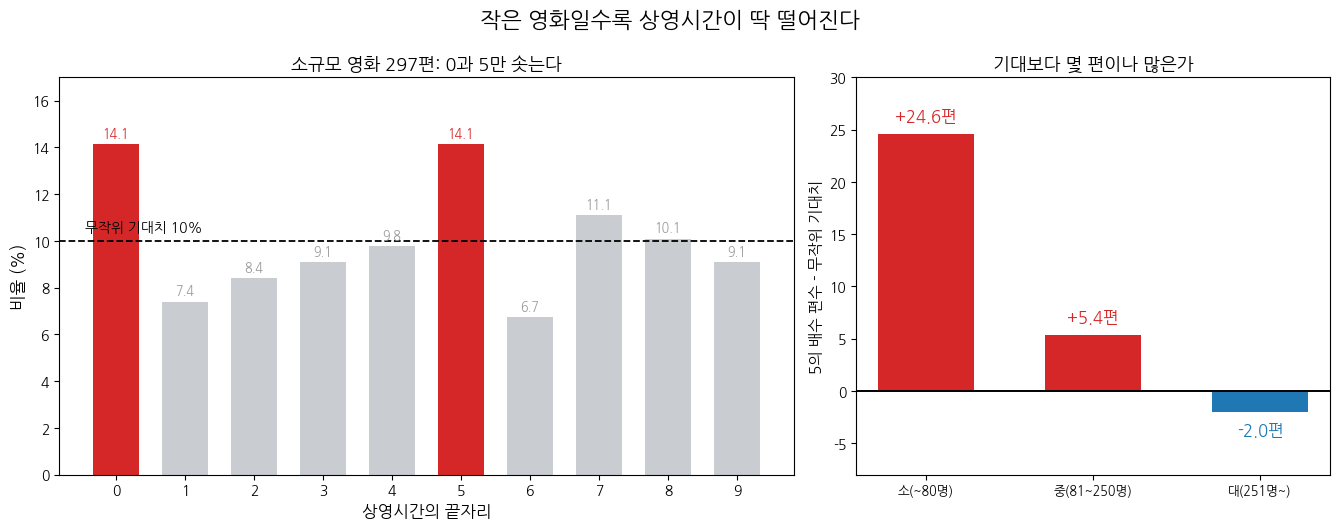

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13.5,5.3),
                         gridspec_kw={'width_ratios': [1.55, 1]})

# ── 왼쪽: 소규모 끝자리 (0·5만 강조) ──
소 = df[df['규모'] == '소(~80명)']
비율 = 소['끝자리'].value_counts(normalize=True).reindex(range(10), fill_value=0) * 100
색 = ['#d62728' if i in (0, 5) else '#c9ccd1' for i in range(10)]

axes[0].bar(비율.index, 비율.values, color=색, width=0.68)
axes[0].axhline(10, color='black', linestyle='--', linewidth=1.3)
axes[0].text(-0.45, 10.4, '무작위 기대치 10%', fontsize=10, ha='left')
for i, v in zip(비율.index, 비율.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9,
                 color='#d62728' if i in (0, 5) else '#999')
axes[0].set_xticks(range(10))
axes[0].set_xlabel('상영시간의 끝자리', fontsize=12)
axes[0].set_ylabel('비율 (%)', fontsize=12)
axes[0].set_title(f'소규모 영화 {len(소)}편: 0과 5만 솟는다', fontsize=13)
axes[0].set_ylim(0, 17)

# ── 오른쪽: 관측 - 기대 편수 (0선 교차) ──
diff = df.groupby('규모', observed=True)['time'].apply(
    lambda s: (s % 5 == 0).sum() - len(s) * 0.2)
색2 = ['#d62728' if v > 0 else '#1f77b4' for v in diff.values]

axes[1].bar(range(3), diff.values, color=색2, width=0.58)
axes[1].axhline(0, color='black', linewidth=1.4)
for i, v in enumerate(diff.values):
    axes[1].text(i, v + (1.2 if v > 0 else -2.2), f'{v:+.1f}편',
                 ha='center', fontsize=12, fontweight='bold',
                 color='#d62728' if v > 0 else '#1f77b4')
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(diff.index, fontsize=9)
axes[1].set_ylabel('5의 배수 편수 - 무작위 기대치', fontsize=11)
axes[1].set_title('기대보다 몇 편이나 많은가', fontsize=13)
axes[1].set_ylim(-8, 30)

fig.suptitle('작은 영화일수록 상영시간이 딱 떨어진다', fontsize=16, y=0.99)
plt.tight_layout()
plt.show()

해석:

소규모 영화는 상영시간 끝자리 0과 5가 각각 14.1%로 공동 1위. 나머지 여덟 자리는 6.7~11.1%에 흩어져 있음. 둘이 동시에 솟았다는 건 "5 단위로 끊어 적는다"는 하나의 원인을 가리김.
기대치 대비 편수로 보면 소 +24.6편, 중 +5.4편, 대 −2.0편 — 규모가 커질수록 줄고, 대규모는 오히려 기준치보다 적음.
상영시간이 5로 끝날 이유는 없음. 실제 길이가 아니라 기재할 때 반올림한 흔적으로 보임. 실제 상영시간이 그런 게 아니라, 작은 영화일수록 상영시간을 대충 반올림해서 기재했을 가능성이 큼.
단, 소 vs 대는 p=0.032지만 전체로는 p=0.074라 확정이 아니라 경향으로 봐야 함.

6번

In [12]:
# ══════════════════════════════════════════════════════
# 0) 효율 정의
#    효율 = 관객수 ÷ 스태프수 (스태프 1명이 데려온 관객)
#    스태프 0명이면 나눗셈이 안 되므로 제외
# ══════════════════════════════════════════════════════
d = df[df['num_staff'] > 0].copy()
d['효율'] = d['box_off_num'] / d['num_staff']
print('스태프 0명이라 제외한 영화: %d편' % (len(df) - len(d)))

# ══════════════════════════════════════════════════════
# 1) 24배가 사실인가 — 규모별 효율
# ══════════════════════════════════════════════════════
print()
print('=' * 60)
print('1) 규모별 효율')
print('=' * 60)
print(d.groupby('규모', observed=True).agg(
    편수=('효율', 'size'),
    스태프중앙=('num_staff', 'median'),
    관객중앙=('box_off_num', 'median'),
    효율중앙=('효율', 'median')).round(0).to_string())

소 = d[d['규모'] == '소(~80명)']
대 = d[d['규모'] == '대(251명~)']
print()
print('효율 %.1f배' % (대['효율'].median() / 소['효율'].median()))

# ══════════════════════════════════════════════════════
# 2) 그 24배는 어디서 왔나 — 분모와 분자로 쪼개기
#    효율 배수 = 관객 배수 ÷ 스태프 배수
# ══════════════════════════════════════════════════════
print()
print('=' * 60)
print('2) 분해')
print('=' * 60)
스태프배수 = 대['num_staff'].median() / 소['num_staff'].median()
관객배수 = 대['box_off_num'].median() / 소['box_off_num'].median()
print('스태프 %.1f배  →  관객 %.1f배' % (스태프배수, 관객배수))
print('관객 %.1f ÷ 스태프 %.1f = %.1f배' % (관객배수, 스태프배수, 관객배수 / 스태프배수))

# ══════════════════════════════════════════════════════
# 3) 단조 증가인가 U자인가  ★ 핵심
#    3칸으로는 안이 뭉개지므로 10등분해서 모양을 본다
# ══════════════════════════════════════════════════════
print()
print('=' * 60)
print('3) 스태프 10분위별 효율')
print('=' * 60)
d['분위'] = pd.qcut(d['num_staff'], 10, labels=False) + 1
분위표 = d.groupby('분위').agg(
    편수=('효율', 'size'),
    스태프중앙=('num_staff', 'median'),
    관객중앙=('box_off_num', 'median'),
    효율중앙=('효율', 'median')).round(0)
print(분위표.to_string())

바닥 = 분위표['효율중앙'].idxmin()
print()
print('효율 최저: %d분위 (스태프 %.0f명, 1명당 %.0f명)'
      % (바닥, 분위표.loc[바닥, '스태프중앙'], 분위표.loc[바닥, '효율중앙']))
print('단조 증가인가:', 분위표['효율중앙'].is_monotonic_increasing)

# ══════════════════════════════════════════════════════
# 4) 분모 함정인가 — 효율 상위가 어떤 영화들인가
#    스태프가 1~3명이면 나눗셈 때문에 효율이 자동으로 커진다
# ══════════════════════════════════════════════════════
print()
print('=' * 60)
print('4) 효율 상위 / 하위')
print('=' * 60)
print('[효율 상위 5편]')
print(d.nlargest(5, '효율')[['title', 'genre', 'num_staff',
                            'box_off_num', '효율']].round(0).to_string(index=False))
print()
print('[대규모인데 효율 하위 3편]')
print(대.nsmallest(3, '효율')[['title', 'genre', 'num_staff',
                             'box_off_num', '효율']].round(0).to_string(index=False))

스태프 0명이라 제외한 영화: 32편

1) 규모별 효율
             편수  스태프중앙       관객중앙    효율중앙
규모                                       
소(~80명)     265   19.0     1958.0   131.0
중(81~250명)  138  136.0    17752.0   129.0
대(251명~)    165  356.0  1169546.0  3144.0

효율 24.0배

2) 분해
스태프 18.7배  →  관객 597.3배
관객 597.3 ÷ 스태프 18.7 = 31.9배

3) 스태프 10분위별 효율
    편수  스태프중앙       관객중앙    효율중앙
분위                              
1   64    3.0     2148.0   870.0
2   60   12.0     1609.0   140.0
3   47   23.0     1958.0    84.0
4   58   44.0     1718.0    37.0
5   55   74.0     3916.0    48.0
6   57  117.0     7721.0    58.0
7   56  192.0    51440.0   243.0
8   57  279.0   616481.0  2099.0
9   57  351.0  1046313.0  3247.0
10  57  471.0  1717566.0  3375.0

효율 최저: 4분위 (스태프 44명, 1명당 37명)
단조 증가인가: False

4) 효율 상위 / 하위
[효율 상위 5편]
             title genre  num_staff  box_off_num        효율
   님아, 그 강을 건너지 마오 다큐멘터리          3      4802169 1600723.0
           울지마, 톤즈 다큐멘터리          1       444327  444327.0
뽀로로 극장판 컴퓨터 왕국 대모험 애니메이션   

결과:

스태프가 3명에서 44명으로 15배 늘어도 관객은 그대로. 2,148명 → 1,718명으로 오히려 줄음. 그러다 스태프 200~280명 사이에서 관객이 12배 증가(51,440 → 616,481). 인력과 관객 사이에 문턱이 존재.

효율(스태프 1명당 관객)은 단조 증가가 아니라 U자 모양. 최저는 큰 영화가 아니라 스태프 44명 안팎(1명당 37명). 문턱 아래에서는 분모만 커지고 분자는 그대로라 효율이 떨어지고, 문턱을 넘으면 분자가 크게 늘어 효율이 올라감.

"큰 영화가 24배 효율적"은 맞지만 오해를 낳을 수 있음. 효율 상위 5편 중 3편이 스태프 1~3명(님아 3명, 울지마 톤즈 1명, 뽀로로 2명)이라, 이 지표는 분모가 작으면 자동으로 커짐.

결론: "클수록 효율적"이 아니라 "문턱을 넘어야 효율이 생긴다".



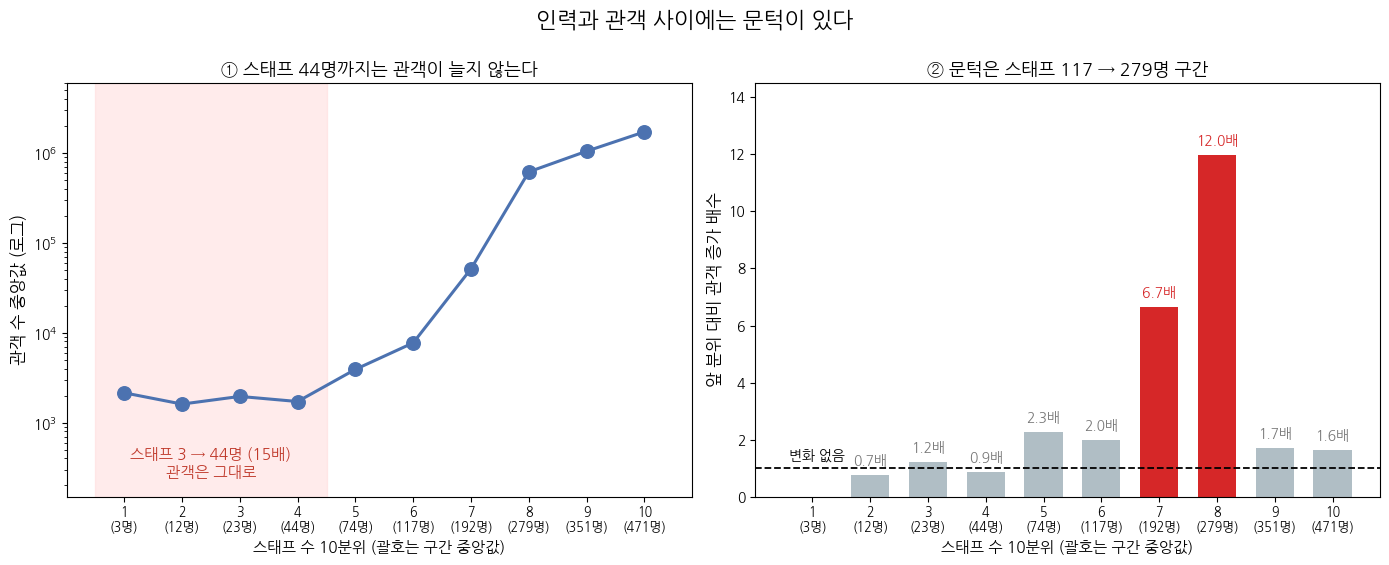

In [14]:
d = df[df['num_staff'] > 0].copy()
d['분위'] = pd.qcut(d['num_staff'], 10, labels=False) + 1

t = d.groupby('분위').agg(스태프중앙=('num_staff', 'median'),
                        관객중앙=('box_off_num', 'median'))
t['배수'] = t['관객중앙'] / t['관객중앙'].shift(1)   # 앞 분위 대비
라벨 = [f'{i}\n({s:.0f}명)' for i, s in zip(t.index, t['스태프중앙'])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), sharex=True)

# ── 왼쪽: 관객수 곡선 ──
ax = axes[0]
ax.axvspan(0.5, 4.5, color='#ffd9d9', alpha=0.5, zorder=0)   # 평평한 구간 배경
ax.plot(t.index, t['관객중앙'], color='#4c72b0', linewidth=2.2, zorder=2)
ax.scatter(t.index, t['관객중앙'], s=95, color='#4c72b0', zorder=3)
ax.set_yscale('log')
ax.text(2.5, 250, '스태프 3 → 44명 (15배)\n관객은 그대로',
        fontsize=11, fontweight='bold', color='#c0392b', ha='center')
ax.set_ylim(150, 6e6)
ax.set_ylabel('관객 수 중앙값 (로그)', fontsize=12)
ax.set_title('① 스태프 44명까지는 관객이 늘지 않는다', fontsize=13)

# ── 오른쪽: 앞 분위 대비 증가 배수 ──
ax = axes[1]
색 = ['#d62728' if (v and v >= 5) else '#b0bec5' for v in t['배수']]
ax.bar(t.index, t['배수'].fillna(0), color=색, width=0.66)
ax.axhline(1, color='black', linestyle='--', linewidth=1.3)
ax.text(0.6, 1.3, '변화 없음', fontsize=10, ha='left')
for i, v in zip(t.index, t['배수']):
    if pd.notna(v):
        ax.text(i, v + 0.35, f'{v:.1f}배', ha='center', fontsize=10,
                fontweight='bold' if v >= 5 else 'normal',
                color='#d62728' if v >= 5 else '#777')
ax.set_ylim(0, 14.5)
ax.set_ylabel('앞 분위 대비 관객 증가 배수', fontsize=12)
ax.set_title('② 문턱은 스태프 117 → 279명 구간', fontsize=13)

for ax in axes:
    ax.set_xticks(t.index)
    ax.set_xticklabels(라벨, fontsize=9)
    ax.set_xlabel('스태프 수 10분위 (괄호는 구간 중앙값)', fontsize=11)

fig.suptitle('인력과 관객 사이에는 문턱이 있다', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

해석:

스태프가 3명에서 44명으로 15배 늘어도 관객은 그대로(2,148 → 1,718명). 로그 축인데도 선이 수평임.

증가 배수로 보면 2-4분위는 0.7 / 1.2 / 0.9배로 1 근처에 머물다가, 7분위 6.7배, 8분위 12.0배로 두 칸만 솟고 다시 1.6-1.7배로 감소. 증가가 스태프 117-279명 한 구간에 몰려 있음.

인력을 조금씩 늘려 관객이 조금씩 느는 구조가 아니라 문턱이 있는 구조. 문턱 아래에서는 사람만 늘어 효율이 떨어지고, 넘으면 관객이 크게 늘어 효율이 올라감.

단, 인과는 아님. 인력을 늘려서 관객이 는 게 아니라 흥행이 예상되는 작품에 인력이 투입된 것일 수 있음.

8번

In [18]:
from scipy import stats

# ══════════════════════════════════════════════════════
# 0) 주요 장르 추리기 + 지표 계산 함수
#    같은 계산을 규모마다 반복하므로 함수로 묶는다
# ══════════════════════════════════════════════════════
주요장르 = df['genre'].value_counts()
주요장르 = 주요장르[주요장르 >= 20].index.tolist()
sub = df[df['genre'].isin(주요장르)].copy()


def 장르효과(데이터, 최소편수=5):
    """규모별로 '장르가 관객수를 얼마나 가르는가'를 네 지표로 계산."""
    결과 = []
    for 규모 in 데이터['규모'].cat.categories:
        g = 데이터[데이터['규모'] == 규모]
        편수 = g['genre'].value_counts()
        g = g[g['genre'].isin(편수[편수 >= 최소편수].index)]   # 표본 적은 장르 제외
        if g['genre'].nunique() < 2:
            continue

        묶음 = g.groupby('genre', observed=True)
        중앙 = 묶음['box_off_num'].median()
        그룹 = [v['log관객수'].values for _, v in 묶음]

        전체 = np.concatenate(그룹)
        ssb = sum(len(a) * (a.mean() - 전체.mean()) ** 2 for a in 그룹)   # 장르 간 변동
        sst = ((전체 - 전체.mean()) ** 2).sum()                          # 전체 변동

        결과.append({
            '규모': 규모,
            '편수': len(전체),
            '장르수': len(그룹),
            '최고최저배수': round(중앙.max() / 중앙.min(), 1),   # 지표 A: 격차
            'R2': round(ssb / sst, 3),                        # 지표 B: 설명력
            'p': round(stats.f_oneway(*그룹)[1], 4),
            '간편차': round(묶음['log관객수'].median().std(), 3),  # 장르끼리 얼마나 다른가
            '내편차': round(묶음['log관객수'].std().mean(), 3),    # 같은 장르 안 흩어짐
        })
    return pd.DataFrame(결과).set_index('규모')


# ══════════════════════════════════════════════════════
# 1) 규모마다 장르 구성이 같은가  ★ 이걸 먼저 봐야 한다
#    구성이 다르면 규모 간 비교 자체가 성립하지 않는다
# ══════════════════════════════════════════════════════
print('=' * 64)
print('1) 규모 x 장르 편수')
print('=' * 64)
구성 = pd.crosstab(sub['규모'], sub['genre'])
print(구성.to_string())

# ══════════════════════════════════════════════════════
# 2) [1차] 주요 장르 전체로 계산 — 교란이 섞인 결과
# ══════════════════════════════════════════════════════
print()
print('=' * 64)
print('2) [1차] 주요 장르 전체')
print('=' * 64)
일차 = 장르효과(sub)
print(일차.to_string())

# ══════════════════════════════════════════════════════
# 3) [교정] 세 규모 모두에 5편 이상 있는 공통 장르만
#    1번에서 대규모에 다큐·애니가 0편인 걸 확인했으므로 맞춰준다
# ══════════════════════════════════════════════════════
공통장르 = 구성.columns[(구성 >= 5).all(axis=0)].tolist()
print()
print('=' * 64)
print('3) [교정] 공통 장르 %s' % 공통장르)
print('=' * 64)
공통 = sub[sub['genre'].isin(공통장르)].copy()
이차 = 장르효과(공통)
print(이차.to_string())

# ══════════════════════════════════════════════════════
# 4) 1차 vs 교정 — 결론이 바뀌는가
# ══════════════════════════════════════════════════════
print()
print('=' * 64)
print('4) 비교')
print('=' * 64)
print(pd.DataFrame({
    '1차_배수': 일차['최고최저배수'], '교정_배수': 이차['최고최저배수'],
    '1차_R2': 일차['R2'], '교정_R2': 이차['R2'],
    '1차_p': 일차['p'], '교정_p': 이차['p']}).to_string())

# ══════════════════════════════════════════════════════
# 5) 시각화에 쓸 표 — 공통 장르의 규모별 중앙값
# ══════════════════════════════════════════════════════
print()
print('=' * 64)
print('5) 공통 장르의 규모별 관객수 중앙값')
print('=' * 64)
표 = 공통.pivot_table(index='규모', columns='genre',
                     values='box_off_num', aggfunc='median', observed=True)
print(표.round(0).to_string())

1) 규모 x 장르 편수
genre       공포  느와르  다큐멘터리  드라마  멜로/로맨스  애니메이션  액션  코미디
규모                                                     
소(~80명)     12    3     90   94      41     16   3   18
중(81~250명)  13    6      3   66      18      5   5   12
대(251명~)    17   18      0   61      19      0  20   23

2) [1차] 주요 장르 전체
             편수  장르수  최고최저배수     R2       p    간편차    내편차
규모                                                       
소(~80명)     271    6    45.0  0.149  0.0000  0.571  0.979
중(81~250명)  125    7    47.3  0.093  0.0679  0.636  1.236
대(251명~)    158    6     3.6  0.111  0.0028  0.213  0.548

3) [교정] 공통 장르 ['공포', '드라마', '멜로/로맨스', '코미디']
             편수  장르수  최고최저배수     R2       p    간편차    내편차
규모                                                       
소(~80명)     165    4     3.1  0.068  0.0095  0.206  1.013
중(81~250명)  109    4    47.3  0.094  0.0156  0.747  1.150
대(251명~)    120    4     2.8  0.031  0.2966  0.188  0.591

4) 비교
            1차_배수  교정_배수  1차_R2  교정_R2    1차_p    교정_p


결과:

세 규모 모두에 5편 이상 있는 공통 장르 4개로 맞추면, 장르 격차가 소규모 3.1배 / 중규모 47.3배 / 대규모 2.8배. 대규모는 p=0.30으로 유의하지도 않음.

작은 영화는 뭘 만들든 660~2,038명, 큰 영화는 뭘 만들든 61만~171만 명. 장르가 결과를 가르는 건 중간 규모뿐.

제한 없이 봤을 때 소규모가 45배로 나온 건 소규모에만 있는 다큐(90편)·애니(16편) 때문. 대규모엔 두 장르가 0편. 교정하니 45 → 3.1배로 감소, 중규모만 47.3배 그대로.

결론: 장르의 영향력은 역U자. 작으면 무엇을 해도 안 되고, 크면 무엇을 해도 되고, 중간에서만 선택이 승부를 가름.

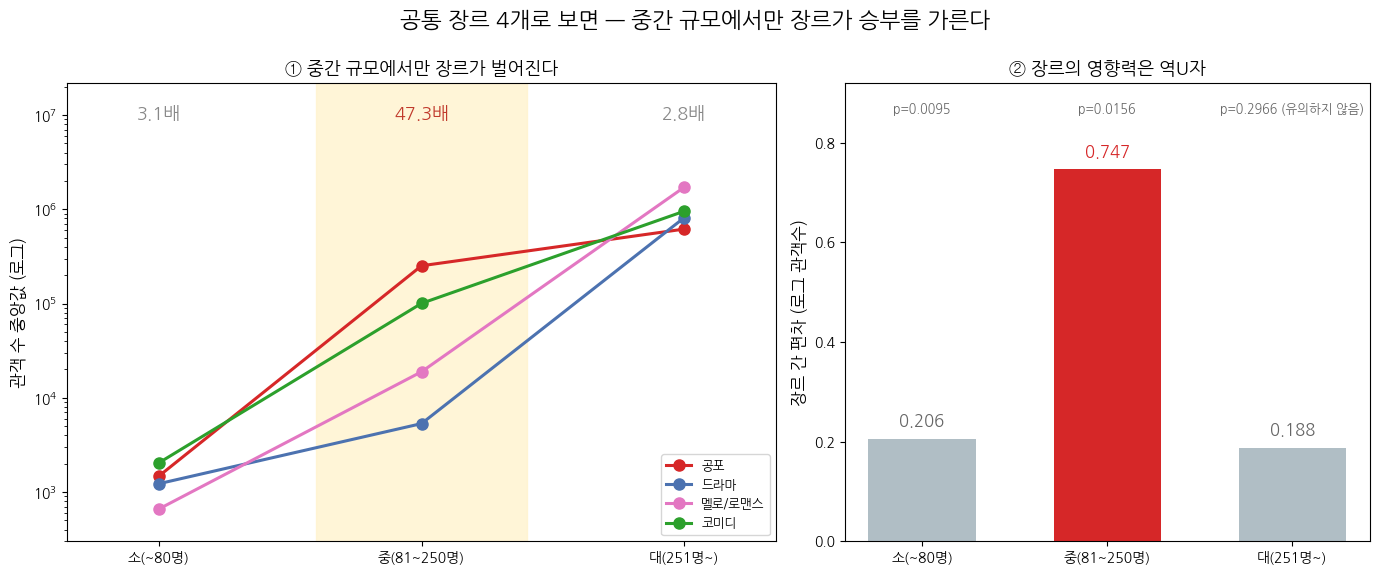

In [19]:
# ══════════════════════════════════════════════════════
# 시각화 — 5번 표(공통 장르 중앙값)를 그림으로
# ══════════════════════════════════════════════════════
간편차 = 이차['간편차']
배수 = 이차['최고최저배수']
x = np.arange(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.7),
                         gridspec_kw={'width_ratios': [1.35, 1]})

# ── 왼쪽: 장르별 선 (부채꼴이 벌어졌다 닫힌다) ──
ax = axes[0]
ax.axvspan(0.6, 1.4, color='#fff3cd', alpha=0.8, zorder=0)   # 중규모 배경 강조

색 = {'공포': '#d62728', '드라마': '#4c72b0',
     '멜로/로맨스': '#e377c2', '코미디': '#2ca02c'}
for g in 공통장르:
    ax.plot(x, 표[g].values, marker='o', markersize=8,
            linewidth=2.2, label=g, color=색[g], zorder=2)

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(표.index, fontsize=10)
ax.set_xlim(-0.35, 2.35)
ax.set_ylim(300, 2.2e7)
ax.set_ylabel('관객 수 중앙값 (로그)', fontsize=12)
ax.set_title('① 중간 규모에서만 장르가 벌어진다', fontsize=13)
ax.legend(fontsize=9, loc='lower right')

for i in x:
    ax.text(i, 9e6, f'{배수.iloc[i]:.1f}배', ha='center', fontsize=13,
            fontweight='bold', color='#c0392b' if i == 1 else '#888')

# ── 오른쪽: 장르 간 편차 (역U자) ──
ax = axes[1]
ax.bar(x, 간편차.values, color=['#b0bec5', '#d62728', '#b0bec5'], width=0.58)
for i, v in enumerate(간편차.values):
    ax.text(i, v + 0.025, f'{v:.3f}', ha='center', fontsize=12,
            fontweight='bold', color='#d62728' if i == 1 else '#666')
for i, p in enumerate(이차['p']):
    꼬리 = ' (유의하지 않음)' if p >= 0.05 else ''
    ax.text(i, 0.86, f'p={p:.4f}{꼬리}', ha='center', fontsize=9, color='#666')

ax.set_xticks(x)
ax.set_xticklabels(간편차.index, fontsize=10)
ax.set_ylim(0, 0.92)
ax.set_ylabel('장르 간 편차 (로그 관객수)', fontsize=12)
ax.set_title('② 장르의 영향력은 역U자', fontsize=13)

fig.suptitle('공통 장르 4개로 보면 — 중간 규모에서만 장르가 승부를 가른다',
             fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

해석:

왼쪽 — 네 장르 선이 소규모에서 붙어 있다가 중규모에서 벌어지고 대규모에서 다시 모임. 부채꼴이 열렸다 닫히는 모양. 대규모에서는 순서까지 뒤집힘 — 중규모 1등이던 공포가 꼴찌(61만)가 되고, 꼴찌였던 드라마가 81만으로 올라섬.

오른쪽 — 장르 간 편차 0.206 / 0.747 / 0.188. 중규모가 나머지의 약 4배. 대규모는 p=0.2966으로 차이를 확인할 수 없는 수준.